# Trade Surveillance with rtbot SQL — Real Market Data

This notebook demonstrates **real-time trade surveillance** patterns using rtbot SQL
against **public Binance trade data** (DOGEUSDT, BTCUSDT, ETHUSDT — 2023-01-01).

### Why rtbot SQL matters for surveillance

Traditional surveillance stacks split alert logic across multiple bespoke services —
a volume-spike detector here, a wash-trade heuristic there, a correlation monitor somewhere else.
Each change requires a code deploy, and auditors cannot read the rules without engineering help.

**rtbot SQL replaces all of that with plain SQL `CREATE MATERIALIZED VIEW` statements.**
Every view is incrementally maintained as each trade arrives — no batch windows,
no custom operator code, no rebuild-the-world reruns. Compliance can read and modify
the rules directly.

### What this notebook proves

| # | Pattern | SQL construct | Academic reference |
|---|---------|---------------|-------------------|
| 1 | Volume-spike / flash-event detection | Cascaded views + `WHERE` filter | Kirilenko et al. (2017) |
| 2 | Wash-trading heuristics | `MOVING_AVERAGE` on 0/1 flag + `WHERE` | Cao et al. (2014) |
| 3 | Cross-instrument correlation break | `FROM btc, eth` + % deviation | Makarov & Schoar (2020) |
| 4 | From notebook to production | Same SQL deploys directly | — |

**Key principle:** All alert detection is done via SQL `WHERE` clauses on
materialized views. Pandas is used only to load CSVs and plot results — never for
data manipulation or filtering.

### Data

Binance Public Trade Data — MIT-licensed, freely redistributable.
Downloaded from `data.binance.vision` and stored in `data/` alongside this notebook
for offline reproducibility.

- **DOGEUSDT**: ~63 K trades (primary demo — right-sized for interactive exploration)
- **BTCUSDT**: 3.2 M trades (subsampled for cross-instrument analysis)
- **ETHUSDT**: 233 K trades (subsampled for cross-instrument analysis)

In [1]:
import pandas as pd
import plotly.graph_objects as go
from rtbot_sql import RtBotSql

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.6f}'.format)

## 1 — Loading Real Trade Data

Binance daily trade CSVs have no header. The columns are:

| Column | Type | Description |
|--------|------|-------------|
| tradeId | int | Exchange-assigned sequential ID |
| price | float | Trade price in USDT |
| qty | float | Base asset quantity |
| quoteQty | float | Quote asset volume (price * qty) |
| time | int | Unix epoch milliseconds |
| isBuyerMaker | bool | `True` = buyer placed the limit order (sell-initiated trade) |
| isBestMatch | bool | Best price match flag |

We load DOGEUSDT in full (~63 K rows) and subsample the first 2 000 trades for the
single-instrument scenarios. For cross-instrument work we take 500 trades each
from BTC and ETH.

In [2]:
CSV_COLS = ['tradeId', 'price', 'qty', 'quoteQty', 'time', 'isBuyerMaker', 'isBestMatch']

doge_full = pd.read_csv('data/DOGEUSDT-trades-2023-01-01.csv', header=None, names=CSV_COLS)
btc_full  = pd.read_csv('data/BTCUSDT-trades-2023-01-01.csv',  header=None, names=CSV_COLS)
eth_full  = pd.read_csv('data/ETHUSDT-trades-2023-01-01.csv',  header=None, names=CSV_COLS)

print(f'DOGEUSDT: {len(doge_full):,} trades')
print(f'BTCUSDT:  {len(btc_full):,} trades')
print(f'ETHUSDT:  {len(eth_full):,} trades')

doge_full.head(5)

DOGEUSDT: 63,270 trades
BTCUSDT:  3,218,355 trades
ETHUSDT:  233,151 trades


,tradeId,price,qty,quoteQty,time,isBuyerMaker,isBestMatch
0,480226473,0.070240,404.000000,28.376960,1672531213340,True,True
1,480226474,0.070250,149.000000,10.467250,1672531220729,False,True
2,480226475,0.070250,7151.000000,502.357750,1672531221482,False,True
3,480226476,0.070250,600.000000,42.150000,1672531221482,False,True
4,480226477,0.070260,284.000000,19.953840,1672531225064,False,True


In [3]:
# Subsample: first 2000 DOGE trades for Sections 2-3.
N_DOGE = 2000
doge = doge_full.head(N_DOGE).copy()

# rtbot only supports DOUBLE columns — encode isBuyerMaker as 0.0 / 1.0.
doge['isBuyerMaker_num'] = doge['isBuyerMaker'].astype(float)

# Readable timestamps for plotting.
doge['event_time'] = pd.to_datetime(doge['time'], unit='ms')

print(f'Using first {N_DOGE} DOGE trades')
print(f'Time range: {doge["event_time"].iloc[0]} -> {doge["event_time"].iloc[-1]}')
doge[['tradeId', 'price', 'qty', 'quoteQty', 'event_time', 'isBuyerMaker']].head(8)

Using first 2000 DOGE trades
Time range: 2023-01-01 00:00:13.340000 -> 2023-01-01 00:31:29.045000


,tradeId,price,qty,quoteQty,event_time,isBuyerMaker
0,480226473,0.070240,404.000000,28.376960,2023-01-01 00:00:13.340,True
1,480226474,0.070250,149.000000,10.467250,2023-01-01 00:00:20.729,False
2,480226475,0.070250,7151.000000,502.357750,2023-01-01 00:00:21.482,False
3,480226476,0.070250,600.000000,42.150000,2023-01-01 00:00:21.482,False
4,480226477,0.070260,284.000000,19.953840,2023-01-01 00:00:25.064,False
5,480226478,0.070260,1716.000000,120.566160,2023-01-01 00:00:25.064,False
6,480226479,0.070260,600.000000,42.156000,2023-01-01 00:00:35.296,False
7,480226480,0.070260,1400.000000,98.364000,2023-01-01 00:00:35.296,False


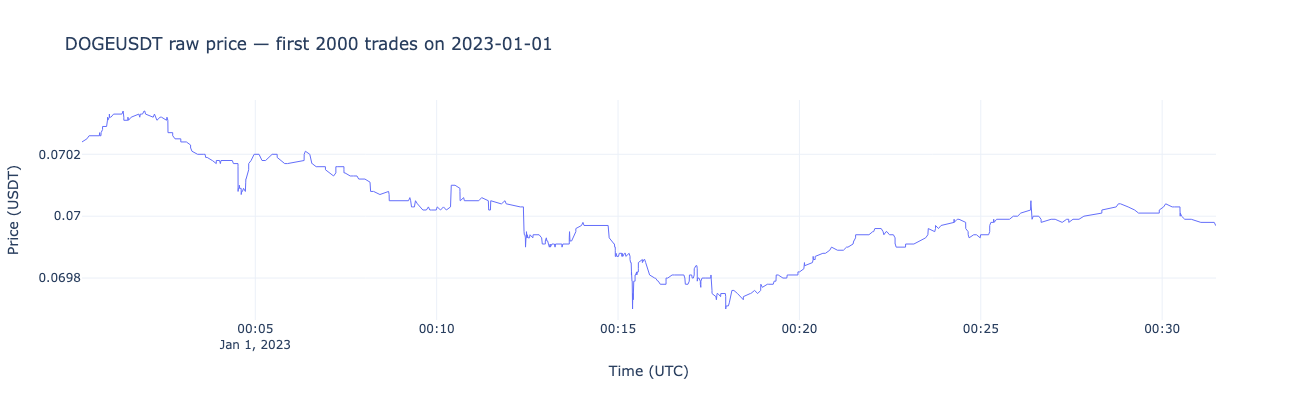

In [4]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=doge['event_time'], y=doge['price'],
    mode='lines', name='DOGEUSDT price',
    line=dict(width=1, color='#636EFA'),
))
fig.update_layout(
    title=f'DOGEUSDT raw price — first {N_DOGE} trades on 2023-01-01',
    xaxis_title='Time (UTC)', yaxis_title='Price (USDT)',
    template='plotly_white', height=400,
)
fig.show()

## 2 — Volume-Spike / Flash-Event Detection

> *"The Flash Crash was caused by a large fundamental trader ... who chose to execute
> a large sell program"* — Kirilenko, Kyle, Samadi & Tuzun (2017),
> *The Flash Crash: High-Frequency Trading in an Electronic Market*, Journal of Finance.

A classic surveillance pattern: flag any trade whose `quoteQty` (notional value)
exceeds a rolling Bollinger-style upper band:

$$\text{quoteQty} > \mu_{50} + 3\,\sigma_{50}$$

rtbot SQL computes the rolling statistics incrementally. We define a materialized
view that tracks the rolling mean and standard deviation of notional value,
then filter for spikes in the query layer.

In [5]:
sql = RtBotSql()
if hasattr(sql, 'configure_time_format'):
    sql.configure_time_format(unit='ms', column_name='time')

sql.execute('''
CREATE STREAM doge_trades (
    price          DOUBLE,
    qty            DOUBLE,
    quote_qty      DOUBLE,
    is_buyer_maker DOUBLE
)
''')

In [6]:
# Materialized view: rolling notional statistics, updated incrementally per trade.
sql.execute('''
CREATE MATERIALIZED VIEW notional_stats AS
  SELECT price, qty, quote_qty,
         MOVING_AVERAGE(quote_qty, 50) AS avg_notional,
         STDDEV(quote_qty, 50) AS std_notional,
         MOVING_AVERAGE(quote_qty, 50) + 3 * STDDEV(quote_qty, 50) AS upper_band
  FROM doge_trades
''')

# Alert view: spike detection via WHERE on downstream view.
# Emits only rows where notional exceeds 3-sigma upper Bollinger band.
sql.execute('''
CREATE MATERIALIZED VIEW volume_spike_alerts AS
  SELECT price, qty, quote_qty, avg_notional, std_notional
  FROM notional_stats
  WHERE quote_qty > avg_notional + 3 * std_notional
''')

In [7]:
# Feed the DOGE trades into the stream.
result = sql.insert_dataframe('doge_trades', doge, column_map={
    'quote_qty': 'quoteQty',
    'is_buyer_maker': 'isBuyerMaker_num',
})
print(result)

Inserted 2,000 rows in 0.13s (15,554 rows/sec)


In [8]:
# Query the view — rtbot computed these rolling stats incrementally, one per trade.
stats = sql.execute('SELECT * FROM notional_stats LIMIT 10')
print(f'notional_stats rows (last 10):')
stats

notional_stats rows (last 10):


,time,price,qty,quote_qty,avg_notional,std_notional,upper_band
0,2023-01-01 00:30:32.094,0.070000,13266.000000,928.620000,353.130389,498.409264,1848.358181
1,2023-01-01 00:30:37.364,0.069990,2859.000000,200.101410,354.163993,498.029516,1848.252540
2,2023-01-01 00:30:41.053,0.069990,208.000000,14.557920,347.862068,500.334222,1848.864735
3,2023-01-01 00:30:43.722,0.069990,384.000000,26.876160,339.036454,502.057987,1845.210416
4,2023-01-01 00:30:46.927,0.069990,5250.000000,367.447500,319.416152,480.511359,1760.950228
5,2023-01-01 00:30:48.104,0.069990,428.000000,29.955720,318.395698,481.081898,1761.641393
6,2023-01-01 00:31:03.935,0.069980,600.000000,41.988000,316.326258,482.062537,1762.513868
7,2023-01-01 00:31:26.129,0.069980,4341.000000,303.783180,322.102321,480.104364,1762.415412
8,2023-01-01 00:31:28.551,0.069970,171.000000,11.964870,322.121819,480.091491,1762.396291
9,2023-01-01 00:31:29.045,0.069970,1659.000000,116.080230,324.083623,479.022574,1761.151344


In [9]:
# Query the plotting overlay (full rolling stats) and the SQL-detected spikes.
stat_df = sql.execute('SELECT * FROM notional_stats LIMIT 2000')

# Volume spikes detected entirely by rtbot SQL — no pandas filtering.
spikes = sql.execute('SELECT * FROM volume_spike_alerts LIMIT 2000')
print(f'Volume spike alerts (SQL HAVING): {len(spikes)} out of {len(stat_df)} trades with stats')
spikes.head(10)

Volume spike alerts (SQL HAVING): 22 out of 952 trades with stats


,time,price,qty,quote_qty,avg_notional,std_notional
0,2023-01-01 00:01:58.488,0.070330,45000.000000,3164.850000,411.830436,791.107146
1,2023-01-01 00:02:35.339,0.070300,164986.000000,11598.515800,668.758430,1770.683265
2,2023-01-01 00:07:13.249,0.070150,40973.000000,2874.255950,400.198354,567.225467
3,2023-01-01 00:10:22.905,0.070030,56464.000000,3954.173920,278.522332,622.549170
4,2023-01-01 00:10:22.912,0.070050,36275.000000,2541.063750,335.751212,698.259597
5,2023-01-01 00:12:23.657,0.069960,55937.000000,3913.352520,562.862065,742.435828
6,2023-01-01 00:12:26.990,0.069910,53260.000000,3723.406600,602.848590,899.518019
7,2023-01-01 00:12:53.599,0.069920,55184.000000,3858.465280,673.497265,1031.957301
8,2023-01-01 00:13:43.240,0.069920,60000.000000,4195.200000,574.342094,758.064841
9,2023-01-01 00:15:23.088,0.069790,18286.000000,1276.179940,224.858663,345.705471


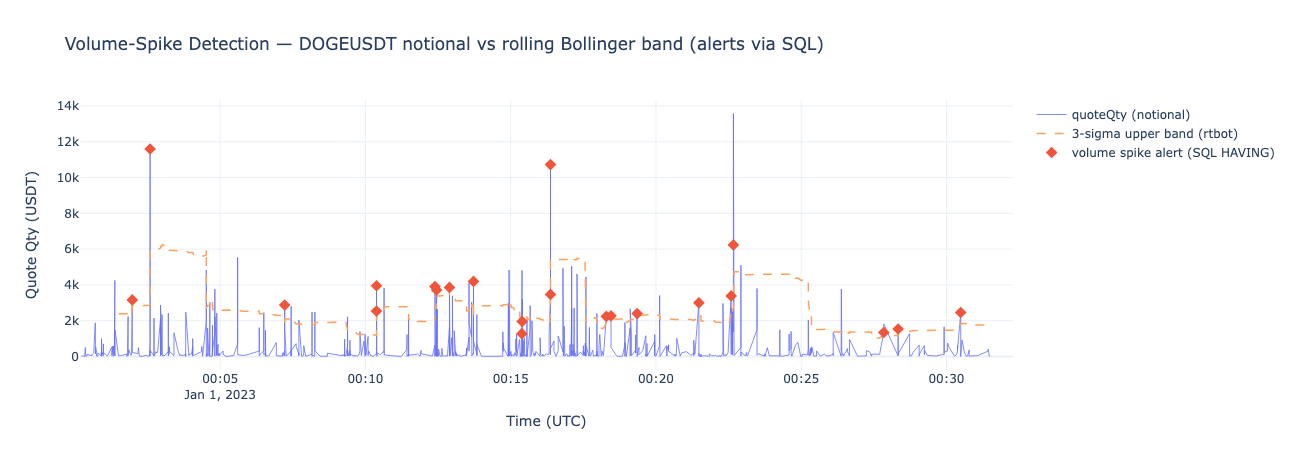

In [10]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=doge['event_time'], y=doge['quoteQty'],
    mode='lines', name='quoteQty (notional)',
    line=dict(width=0.8, color='#636EFA'),
))
fig.add_trace(go.Scatter(
    x=stat_df['time'], y=stat_df['upper_band'],
    mode='lines', name='3-sigma upper band (rtbot)',
    line=dict(width=1.5, color='#FFA15A', dash='dash'),
))
if len(spikes) > 0:
    fig.add_trace(go.Scatter(
        x=spikes['time'], y=spikes['quote_qty'],
        mode='markers', name='volume spike alert (SQL HAVING)',
        marker=dict(size=9, color='#EF553B', symbol='diamond'),
    ))
fig.update_layout(
    title='Volume-Spike Detection — DOGEUSDT notional vs rolling Bollinger band (alerts via SQL)',
    xaxis_title='Time (UTC)', yaxis_title='Quote Qty (USDT)',
    template='plotly_white', height=450,
)
fig.show()

**Business value.** A single SQL view replaces a custom volume-spike detection
service. Threshold changes (`3 * STDDEV` -> `2.5 * STDDEV`, window `50` -> `100`)
are SQL edits - no code deploy, no integration test. Compliance can read and
audit the rule directly. The same `MOVING_AVERAGE + STDDEV` pattern detects
temperature breaches in cold-chain monitoring (Notebook 1) and volume spikes
in financial markets - **one engine, universal patterns.**

## 3 — Wash-Trading Heuristics

> *"Wash trading inflates volume ... accounting for up to 70% of reported volume"*
> — Cao, Chen & Shan (2014), *Detecting Wash Trade in Financial Markets*.

A simple heuristic: in normal markets, buy-initiated and sell-initiated trades are
roughly balanced over any short window. If one side dominates consistently, it may
indicate self-dealing (wash trading) or aggressive directional spoofing.

We compute a **rolling sell-initiated fraction** over the last 100 trades:

$$\text{sell\_ratio} = \text{MOVING\_AVERAGE}(\text{is\_buyer\_maker},\; 100)$$

Since `is_buyer_maker` is 0 or 1, `MOVING_AVERAGE` gives exactly the fraction
of sell-initiated trades in the window. We flag periods where this ratio
exceeds 0.65 or drops below 0.35 (strong directional imbalance).

In [11]:
# Materialized view: rolling sell-initiated fraction.
sql.execute('''
CREATE MATERIALIZED VIEW trade_side_ratio AS
  SELECT price, qty, is_buyer_maker,
         MOVING_AVERAGE(is_buyer_maker, 100) AS sell_ratio
  FROM doge_trades
''')

sql.execute('''
CREATE MATERIALIZED VIEW wash_trade_alerts AS
  SELECT price, qty, is_buyer_maker, sell_ratio
  FROM trade_side_ratio
  WHERE sell_ratio > 0.65 OR sell_ratio < 0.35
''')

In [12]:
# Query full rolling output from rtbot (no pandas rolling).
side_df = sql.execute('SELECT * FROM trade_side_ratio LIMIT 2000')
# time is returned directly by rtbot SQL output formatting.
wash_alerts = sql.execute('SELECT * FROM wash_trade_alerts LIMIT 2000')
if len(wash_alerts) > 0:
    wash_alerts = wash_alerts.copy()
print(f'trade_side_ratio rows: {len(side_df)}, rtbot wash alerts: {len(wash_alerts)}')
side_df.tail(10)

trade_side_ratio rows: 902, rtbot wash alerts: 173


,time,price,qty,is_buyer_maker,sell_ratio
892,2023-01-01 00:30:32.094,0.070000,13266.000000,1.000000,0.550000
893,2023-01-01 00:30:37.364,0.069990,2859.000000,0.000000,0.540000
894,2023-01-01 00:30:41.053,0.069990,208.000000,0.000000,0.530000
895,2023-01-01 00:30:43.722,0.069990,384.000000,0.000000,0.520000
896,2023-01-01 00:30:46.927,0.069990,5250.000000,0.000000,0.510000
897,2023-01-01 00:30:48.104,0.069990,428.000000,0.000000,0.500000
898,2023-01-01 00:31:03.935,0.069980,600.000000,1.000000,0.500000
899,2023-01-01 00:31:26.129,0.069980,4341.000000,0.000000,0.490000
900,2023-01-01 00:31:28.551,0.069970,171.000000,1.000000,0.490000
901,2023-01-01 00:31:29.045,0.069970,1659.000000,1.000000,0.490000


In [13]:
# Show the strongest alert points generated by rtbot SQL.
wash_alerts.sort_values('sell_ratio').head(10)

,time,price,qty,is_buyer_maker,sell_ratio
110,2023-01-01 00:16:33.489,0.069810,173.000000,0.000000,0.230000
107,2023-01-01 00:16:22.244,0.069800,19611.000000,0.000000,0.230000
108,2023-01-01 00:16:22.246,0.069800,6411.000000,0.000000,0.230000
105,2023-01-01 00:16:22.235,0.069800,49733.000000,0.000000,0.240000
111,2023-01-01 00:16:38.204,0.069810,4791.000000,1.000000,0.240000
109,2023-01-01 00:16:29.382,0.069810,12300.000000,1.000000,0.240000
106,2023-01-01 00:16:22.240,0.069800,153697.000000,0.000000,0.240000
114,2023-01-01 00:16:50.491,0.069800,9692.000000,1.000000,0.240000
113,2023-01-01 00:16:48.852,0.069810,315.000000,0.000000,0.240000
115,2023-01-01 00:16:50.492,0.069800,13705.000000,1.000000,0.250000


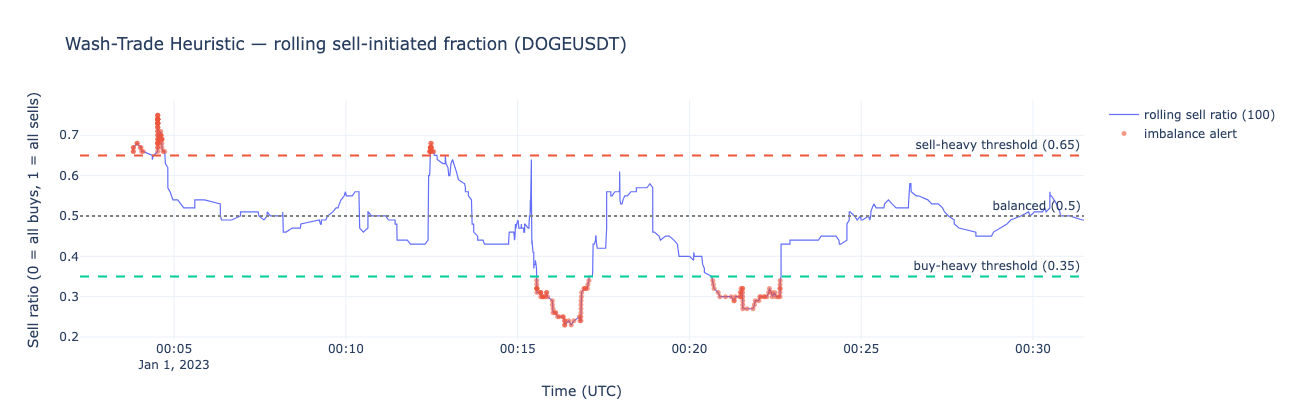

In [14]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=side_df['time'], y=side_df['sell_ratio'],
    mode='lines', name='rolling sell ratio (100)',
    line=dict(width=1.2, color='#636EFA'),
))
fig.add_hline(y=0.65, line_dash='dash', line_color='#EF553B',
              annotation_text='sell-heavy threshold (0.65)')
fig.add_hline(y=0.35, line_dash='dash', line_color='#00CC96',
              annotation_text='buy-heavy threshold (0.35)')
fig.add_hline(y=0.5, line_dash='dot', line_color='gray',
              annotation_text='balanced (0.5)')
if len(wash_alerts) > 0:
    fig.add_trace(go.Scatter(
        x=wash_alerts['time'], y=wash_alerts['sell_ratio'],
        mode='markers', name='imbalance alert',
        marker=dict(size=5, color='#EF553B', symbol='circle', opacity=0.6),
    ))
fig.update_layout(
    title='Wash-Trade Heuristic — rolling sell-initiated fraction (DOGEUSDT)',
    xaxis_title='Time (UTC)',
    yaxis_title='Sell ratio (0 = all buys, 1 = all sells)',
    template='plotly_white', height=420,
)
fig.show()

**Business value.** The wash-trade heuristic is a rolling average on a boolean
flag - one SQL view, zero custom code. Tuning the window size or imbalance
threshold is a SQL constant change. The same technique applies to IoT sensor
uptime monitoring (rolling average of a 0/1 health flag). rtbot makes cross-domain
pattern reuse trivial.

## 4 — Cross-Instrument Correlation Break

> *"Bitcoin prices across exchanges are tightly correlated ... deviations can signal
> market stress or manipulation"* — Makarov & Schoar (2020),
> *Trading and Arbitrage in Cryptocurrency Markets*, Journal of Financial Economics.

BTC and ETH normally move together. A divergence in their rolling statistics
can signal market stress, exchange issues, or manipulation.

This section uses a **true multi-source SQL view** (`FROM btc_trades btc, eth_trades eth`)
so cross-instrument logic is expressed and maintained directly in rtbot SQL.

We subsample ~5000 trades across the full day for each instrument so the price
actually moves, then feed them via `insert_dataframe`. rtbot handles the
cross-stream synchronization — no pandas `merge_asof` needed.

In [15]:
# Subsample ~5000 trades spread across the full day for each instrument.
# Every Nth row gives uniform coverage of the 24-hour period.
N_CROSS = 5000

btc_sorted = btc_full.sort_values('time').reset_index(drop=True)
eth_sorted = eth_full.sort_values('time').reset_index(drop=True)

btc_step = max(1, len(btc_sorted) // N_CROSS)
eth_step = max(1, len(eth_sorted) // N_CROSS)

btc = btc_sorted.iloc[::btc_step].head(N_CROSS)[['time', 'price', 'qty', 'quoteQty']].copy()
eth = eth_sorted.iloc[::eth_step].head(N_CROSS)[['time', 'price', 'qty', 'quoteQty']].copy()

btc_start = pd.to_datetime(int(btc['time'].iloc[0]), unit='ms')
btc_end   = pd.to_datetime(int(btc['time'].iloc[-1]), unit='ms')
eth_start = pd.to_datetime(int(eth['time'].iloc[0]), unit='ms')
eth_end   = pd.to_datetime(int(eth['time'].iloc[-1]), unit='ms')

print(f'BTC: {len(btc)} trades, every {btc_step}th row, {btc_start} -> {btc_end}')
print(f'ETH: {len(eth)} trades, every {eth_step}th row, {eth_start} -> {eth_end}')
print(f'BTC price range: {btc["price"].min():.2f} - {btc["price"].max():.2f}')
print(f'ETH price range: {eth["price"].min():.2f} - {eth["price"].max():.2f}')

BTC: 5000 trades, every 643th row, 2023-01-01 00:00:00.001000 -> 2023-01-01 23:58:17.063000
ETH: 5000 trades, every 46th row, 2023-01-01 00:00:00 -> 2023-01-01 23:40:59.943000
BTC price range: 16500.00 - 16627.65
ETH price range: 1190.70 - 1204.58


In [16]:
sql2 = RtBotSql()
if hasattr(sql2, 'configure_time_format'):
    sql2.configure_time_format(unit='ms', column_name='time')

sql2.execute('CREATE STREAM btc_trades (price DOUBLE, qty DOUBLE, quote_qty DOUBLE)')
sql2.execute('CREATE STREAM eth_trades (price DOUBLE, qty DOUBLE, quote_qty DOUBLE)')

# Rolling stats with percentage deviation — normalizes BTC ($16K) and ETH ($1.2K)
# to the same scale so divergence comparison is meaningful.
sql2.execute('''
CREATE MATERIALIZED VIEW cross_stats AS
  SELECT btc.price AS btc_price,
         eth.price AS eth_price,
         MOVING_AVERAGE(btc.price, 50) AS btc_ma,
         MOVING_AVERAGE(eth.price, 50) AS eth_ma,
         (btc.price - MOVING_AVERAGE(btc.price, 50)) / MOVING_AVERAGE(btc.price, 50) AS btc_pct_dev,
         (eth.price - MOVING_AVERAGE(eth.price, 50)) / MOVING_AVERAGE(eth.price, 50) AS eth_pct_dev
  FROM btc_trades btc, eth_trades eth
''')

# Divergence alerts — percentage deviation difference > 0.1%.
# When BTC and ETH deviate by more than 0.1% relative to their rolling means,
# it signals a potential correlation break worth investigating.
sql2.execute('''
CREATE MATERIALIZED VIEW divergence_alerts AS
  SELECT btc_price, eth_price, btc_pct_dev, eth_pct_dev,
         ABS(btc_pct_dev - eth_pct_dev) AS divergence_pct
  FROM cross_stats
  WHERE ABS(btc_pct_dev - eth_pct_dev) > 0.001
''')

# Rolling Pearson correlation — (E[XY] - E[X]E[Y]) / (sigma_X * sigma_Y).
# Guard on rolling std avoids division-by-zero when a window is flat.
sql2.execute('''
CREATE MATERIALIZED VIEW cross_correlation AS
  SELECT btc_price, eth_price,
         MOVING_AVERAGE(btc_price, 60) AS btc_ma_60,
         MOVING_AVERAGE(eth_price, 60) AS eth_ma_60,
         MOVING_AVERAGE(btc_price * eth_price, 60) AS btc_eth_ma_60,
         MOVING_STD(btc_price, 60) AS btc_std_60,
         MOVING_STD(eth_price, 60) AS eth_std_60,
         (btc_eth_ma_60 - btc_ma_60 * eth_ma_60) / (btc_std_60 * eth_std_60) AS corr_60
  FROM cross_stats
  WHERE btc_std_60 > 0 AND eth_std_60 > 0
''')

In [17]:
# Feed both streams via insert_dataframe — clean, consistent with Sections 2-3.
result_btc = sql2.insert_dataframe('btc_trades', btc, column_map={'quote_qty': 'quoteQty'})
result_eth = sql2.insert_dataframe('eth_trades', eth, column_map={'quote_qty': 'quoteQty'})

print(result_btc)
print(result_eth)

Inserted 5,000 rows in 0.09s (53,910 rows/sec)
Inserted 5,000 rows in 0.93s (5,389 rows/sec)


In [18]:
stats = sql2.execute('SELECT * FROM cross_stats LIMIT 10000')
corr_stats = sql2.execute('SELECT * FROM cross_correlation LIMIT 10000')
alerts = sql2.execute('SELECT * FROM divergence_alerts LIMIT 10000')

print(f'cross_stats rows: {len(stats)}, correlation rows: {len(corr_stats)}, divergence alerts: {len(alerts)}')
if len(alerts) > 0:
    print(f'\nSample alerts (percentage divergence):')
    display(alerts.head(10))

cross_stats rows: 4912, correlation rows: 4794, divergence alerts: 38

Sample alerts (percentage divergence):


,time,btc_price,eth_price,btc_pct_dev,eth_pct_dev,divergence_pct
0,2023-01-01 00:34:53.850,16528.090000,1193.720000,-0.000633,-0.002001,0.001368
1,2023-01-01 00:35:54.425,16525.870000,1193.690000,-0.000622,-0.001698,0.001075
2,2023-01-01 03:00:12.467,16546.380000,1194.200000,0.000051,-0.001043,0.001094
3,2023-01-01 03:00:19.111,16536.460000,1193.310000,-0.000527,-0.001661,0.001134
4,2023-01-01 03:00:21.644,16536.460000,1193.290000,-0.000520,-0.001641,0.001122
5,2023-01-01 03:00:23.521,16536.460000,1193.040000,-0.000512,-0.001810,0.001298
6,2023-01-01 03:00:23.886,16536.460000,1192.880000,-0.000507,-0.001903,0.001396
7,2023-01-01 03:00:24.219,16533.750000,1192.970000,-0.000664,-0.001789,0.001125
8,2023-01-01 03:00:30.248,16536.880000,1193.110000,-0.000453,-0.001571,0.001117
9,2023-01-01 03:00:32.873,16534.750000,1193.030000,-0.000569,-0.001596,0.001027


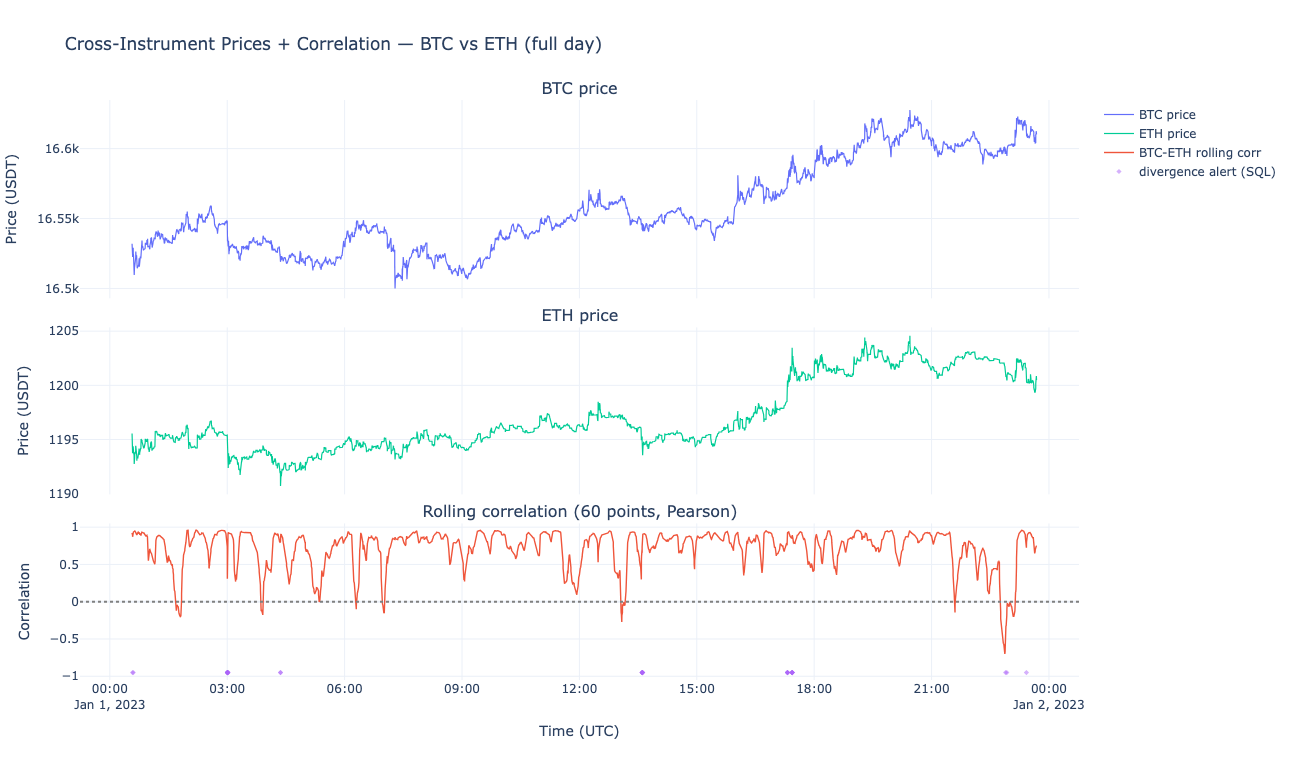

In [19]:
from plotly.subplots import make_subplots

corr_window = 60
corr_df = corr_stats.copy()

fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
    row_heights=[0.38, 0.32, 0.30],
    subplot_titles=(
        'BTC price',
        'ETH price',
        f'Rolling correlation ({corr_window} points, Pearson)'
    ),
)

fig.add_trace(go.Scatter(
    x=corr_df['time'], y=corr_df['btc_price'],
    mode='lines', name='BTC price',
    line=dict(width=1.2, color='#636EFA'),
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=corr_df['time'], y=corr_df['eth_price'],
    mode='lines', name='ETH price',
    line=dict(width=1.2, color='#00CC96'),
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=corr_df['time'], y=corr_df['corr_60'],
    mode='lines', name='BTC-ETH rolling corr',
    line=dict(width=1.4, color='#EF553B'),
), row=3, col=1)

if len(alerts) > 0:
    alert_times = alerts['time']
    fig.add_trace(go.Scatter(
        x=alert_times, y=[-0.95] * len(alert_times),
        mode='markers', name='divergence alert (SQL)',
        marker=dict(size=4, color='#AB63FA', symbol='diamond', opacity=0.5),
    ), row=3, col=1)

fig.add_hline(y=0, line_dash='dot', line_color='gray', row=3, col=1)
fig.update_yaxes(title_text='Price (USDT)', row=1, col=1)
fig.update_yaxes(title_text='Price (USDT)', row=2, col=1)
fig.update_yaxes(title_text='Correlation', range=[-1.05, 1.05], row=3, col=1)
fig.update_xaxes(title_text='Time (UTC)', row=3, col=1)
fig.update_layout(
    title='Cross-Instrument Prices + Correlation — BTC vs ETH (full day)',
    template='plotly_white',
    height=760,
)
fig.show()

**Business value.** Cross-stream correlation-break monitoring is usually the hardest
pattern to implement in streaming stacks: two unbounded streams, synchronized rolling
state, and real-time co-movement checks. In rtbot SQL, the full logic lives in
`CREATE MATERIALIZED VIEW ... FROM stream_a, stream_b` and alert SQL on top.
The engine handles synchronization, state management, and incremental updates.
**This is the pattern that typically requires a dedicated team and months of
engineering. Here it's one SQL statement.**

## 5 — From Notebook to Production

The SQL statements in this notebook are not prototypes — they **are** the production rules.

```sql
-- These exact statements deploy to a production rtbot instance:

CREATE STREAM doge_trades (price DOUBLE, qty DOUBLE, quote_qty DOUBLE, is_buyer_maker DOUBLE)

CREATE MATERIALIZED VIEW volume_spike_alerts AS
  SELECT price, qty, quote_qty, ...
  FROM doge_trades
  HAVING quote_qty > MOVING_AVERAGE(quote_qty, 50) + 3 * STDDEV(quote_qty, 50)

CREATE MATERIALIZED VIEW wash_trade_alerts AS
  SELECT price, qty, is_buyer_maker, sell_ratio
  FROM trade_side_ratio
  WHERE sell_ratio > 0.65 OR sell_ratio < 0.35

CREATE MATERIALIZED VIEW divergence_alerts AS
  SELECT btc_price, eth_price, btc_pct_dev, eth_pct_dev, ...
  FROM cross_stats
  WHERE ABS(btc_pct_dev - eth_pct_dev) > 0.0015 OR co_move < -0.000001
```

**No code translation. No ETL pipeline. No deployment artifact.**

The notebook is the development environment. The SQL is the production artifact.
A compliance officer can read the alert rules. A quant can tune the thresholds.
Neither needs to deploy code or wait for engineering.

| What changes | Traditional stack | rtbot SQL |
|---|---|---|
| Alert threshold | Code change + deploy + test | Edit SQL constant |
| New instrument | New service + integration | `CREATE STREAM` + feed |
| Cross-instrument rule | Months of engineering | One `FROM a, b` view |
| Audit trail | Reverse-engineer code | Read the SQL |

## References

1. Kirilenko, A., Kyle, A., Samadi, M. & Tuzun, T. (2017). *The Flash Crash:
   High-Frequency Trading in an Electronic Market.* Journal of Finance, 72(3), 967-998.
2. Cao, Y., Chen, Y. & Shan, B. (2014). *Detecting Wash Trade in Financial Markets.*
   Working paper.
3. Makarov, I. & Schoar, A. (2020). *Trading and Arbitrage in Cryptocurrency Markets.*
   Journal of Financial Economics, 135(2), 293-319.